In [1]:
# ==============================================================================
# PASO 1: Importar Librerías
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
data = pd.read_csv('ConsumoElectrico.csv')
# Mostrar las primeras 5 filas
data.head()


,Hora_del_Dia,Temperatura_C,Humedad_Porcentaje,Consumo_Maximo_MW
0,6,14.0,56.0,61.9
1,19,13.5,53.9,103.3
2,14,6.1,67.0,81.7
3,10,23.3,68.1,110.2
4,7,20.1,32.7,104.6


In [2]:
# Definir Características (X) y Etiqueta (y)
X = data[['Hora_del_Dia', 'Temperatura_C', 'Humedad_Porcentaje']]
y = data['Consumo_Maximo_MW']

In [3]:
# Dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Tamaño del conjunto de Entrenamiento (80%): {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de Prueba (20%): {X_test.shape[0]} muestras")
print("\n")


Tamaño del conjunto de Entrenamiento (80%): 160 muestras
Tamaño del conjunto de Prueba (20%): 40 muestras




In [4]:
# ==============================================================================
# PASO 4: Entrenamiento del Modelo (Random Forest Regressor)
# ==============================================================================
# Inicializar el modelo Random Forest para Regresión
# n_estimators=100 significa que construiremos 100 árboles de decisión
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
# Entrenar el modelo con los datos de entrenamiento
print("--- Entrenando el modelo Random Forest... ---")
rf_model.fit(X_train, y_train)
print("¡Entrenamiento completado!")
print("\n")


--- Entrenando el modelo Random Forest... ---
¡Entrenamiento completado!




In [5]:
# ==============================================================================
# PASO 5: Predicción y Evaluación
# ==============================================================================
# Hacer predicciones sobre el conjunto de prueba
y_pred = rf_model.predict(X_test)
# Calcular métricas de evaluación
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("--- Evaluación del Modelo ---")
print(f"Error Absoluto Medio (MAE): {mae:.2f} MW")
print(f"Coeficiente de Determinación (R²): {r2:.4f} (Cercano a 1 es mejor)")

--- Evaluación del Modelo ---
Error Absoluto Medio (MAE): 5.49 MW
Coeficiente de Determinación (R²): 0.9152 (Cercano a 1 es mejor)


In [6]:
# ==============================================================================
# 1. Crear un DataFrame de Comparación
# ==============================================================================
# Crear un DataFrame a partir de los datos de prueba originales (X_test)
df_comparacion = X_test.copy()
# Agregar la columna de los valores Reales (Consumo_Maximo_MW)
# Usamos .values para asegurar que el índice no cause problemas.
df_comparacion['Consumo_Real_MW'] = y_test.values
# Agregar la columna de los valores Predichos (y_pred)
df_comparacion['Consumo_Predicho_MW'] = y_pred
# Calcular la diferencia (Error o Residual)
df_comparacion['Error_MW'] = df_comparacion['Consumo_Real_MW'] - df_comparacion['Consumo_Predicho_MW']
# Ordenar por el error absoluto para ver dónde se equivocó más el modelo
df_comparacion['Error_Absoluto'] = abs(df_comparacion['Error_MW'])
df_comparacion = df_comparacion.sort_values(by='Error_Absoluto', ascending=False)
print("--- Comparación de Predicciones y Valores Reales (Top 50 Errores) --- \n")
df_comparacion.head(10)

--- Comparación de Predicciones y Valores Reales (Top 50 Errores) --- 



,Hora_del_Dia,Temperatura_C,Humedad_Porcentaje,Consumo_Real_MW,Consumo_Predicho_MW,Error_MW,Error_Absoluto
132,14,20.0,89.6,122.9,108.425833,14.474167,14.474167
65,1,5.2,84.3,35.3,48.284200,-12.984200,12.984200
125,11,15.8,43.4,84.3,97.042702,-12.742702,12.742702
18,20,24.0,68.6,104.2,115.757319,-11.557319,11.557319
67,21,21.5,49.2,62.2,73.361000,-11.161000,11.161000
186,11,12.4,81.9,104.3,93.182367,11.117633,11.117633
78,14,22.0,77.4,105.4,116.252500,-10.852500,10.852500
170,22,33.9,82.0,93.5,82.837000,10.663000,10.663000
55,11,31.6,75.1,130.9,122.018108,8.881892,8.881892
93,12,13.4,34.4,90.2,98.874500,-8.674500,8.674500


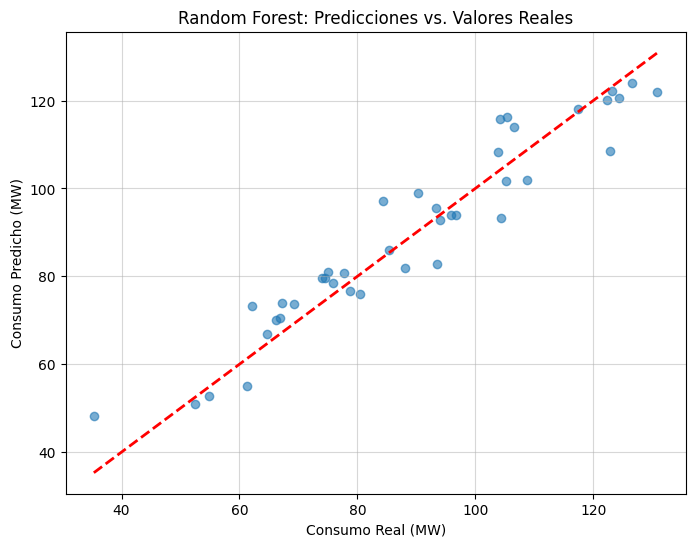

In [7]:
# ==============================================================================
# PASO 7: Visualización
# ==============================================================================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Consumo Real (MW)")
plt.ylabel("Consumo Predicho (MW)")
plt.title("Random Forest: Predicciones vs. Valores Reales")
plt.grid(True, alpha=0.5)
plt.show()

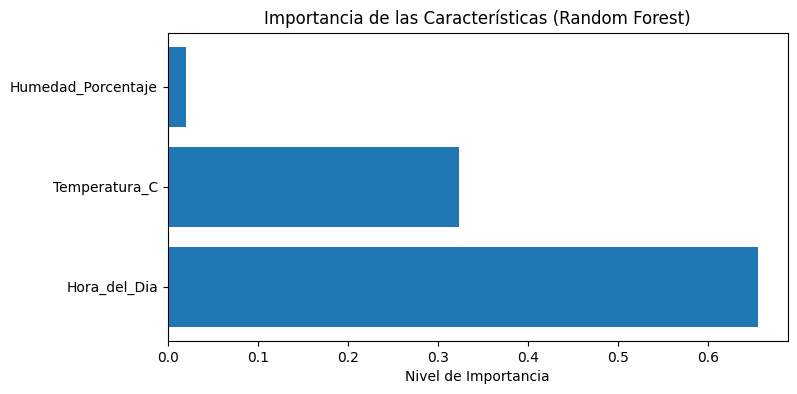

In [8]:
# Importancia de las Características
importancia = rf_model.feature_importances_
caracteristicas = X.columns
plt.figure(figsize=(8, 4))
plt.barh(caracteristicas, importancia)
plt.title("Importancia de las Características (Random Forest)")
plt.xlabel("Nivel de Importancia")
plt.show()


In [9]:
# Datos de pronósticos para mañana (p.ej., el pico de calor a las 17:00)
datos_futuros = pd.DataFrame({
'Hora_del_Dia': [17, 3, 10], # 5 PM, 3 AM, 10 AM
'Temperatura_C': [35.0, 11.0, 25.0], # Temperatura máxima
'Humedad_Porcentaje': [40.0, 75.0, 60.0]
                               })
datos_futuros

,Hora_del_Dia,Temperatura_C,Humedad_Porcentaje
0,17,35.0,40.0
1,3,11.0,75.0
2,10,25.0,60.0


In [10]:
predicciones_futuras = rf_model.predict(datos_futuros)
print("--- Predicciones para Mañana ---")
for i in range(len(datos_futuros)):
    print(f"Pronóstico para las {int(datos_futuros.iloc[i]['Hora_del_Dia']):02d}:00 (Temp: {datos_futuros.iloc[i]['Temperatura_C']}°C, Humedad: {datos_futuros.iloc[i]['Humedad_Porcentaje']}%) - Consumo Predicho: {predicciones_futuras[i]:.2f} MW")



--- Predicciones para Mañana ---
Pronóstico para las 17:00 (Temp: 35.0°C, Humedad: 40.0%) - Consumo Predicho: 121.72 MW
Pronóstico para las 03:00 (Temp: 11.0°C, Humedad: 75.0%) - Consumo Predicho: 51.64 MW
Pronóstico para las 10:00 (Temp: 25.0°C, Humedad: 60.0%) - Consumo Predicho: 113.07 MW
